# Restaurant Data Analysis Project

Internship: Cognifyz Technologies  
Tools Used: Python, Pandas, NumPy, Matplotlib  

## Dataset Description
This dataset contains information about restaurants including their location, cuisines, ratings, price ranges, and service features such as online delivery.  
The objective is to analyze restaurant trends and identify patterns in customer preferences and restaurant performance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("dataset.csv")
df.head()


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [3]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='str')

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   str    
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   str    
 4   Address               9551 non-null   str    
 5   Locality              9551 non-null   str    
 6   Locality Verbose      9551 non-null   str    
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   str    
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   str    
 12  Has Table booking     9551 non-null   str    
 13  Has Online delivery   9551 non-null   str    
 14  Is delivering now     9551 non-null   str    
 15  Switch to order menu  9551 non-n

In [14]:

cuisine_counts = df['Cuisines'].str.split(', ').explode().value_counts()
top3 = cuisine_counts.head(3)
print("Top 3 Cuisines:")
print(top3)
total = len(df)
percentage = ((top3 / total) * 100).round(2)
print("\nPercentage of Restaurants:")
print(percentage)

Top 3 Cuisines:
Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

Percentage of Restaurants:
Cuisines
North Indian    41.46
Chinese         28.64
Fast Food       20.79
Name: count, dtype: float64


## Task 1 – Top Cuisines

Observation:
The analysis identifies the most frequently occurring cuisines in the dataset.  
The top cuisines represent the most popular food types offered by restaurants.

Understanding cuisine popularity helps identify customer preferences and dominant food categories in the market.

In [15]:
city_counts = df['City'].value_counts()

print("City with highest number of restaurants:")
print(city_counts.head(1))

City with highest number of restaurants:
City
New Delhi    5473
Name: count, dtype: int64


In [16]:
city_avg = df.groupby('City')['Aggregate rating'].mean()

print("\nAverage rating for each city:")
print(city_avg)


Average rating for each city:
City
??stanbul          4.292857
Abu Dhabi          4.300000
Agra               3.965000
Ahmedabad          4.161905
Albany             3.555000
                     ...   
Waterloo           3.650000
Weirton            3.900000
Wellington City    4.250000
Winchester Bay     3.200000
Yorkton            3.300000
Name: Aggregate rating, Length: 141, dtype: float64


In [17]:
print("\nCity with highest average rating:")
print(city_avg.sort_values(ascending=False).head(1))


City with highest average rating:
City
Inner City    4.9
Name: Aggregate rating, dtype: float64


## Task 2 – City with Highest Number of Restaurants

Observation:
The city with the highest number of restaurants indicates a dense food market and strong restaurant competition.

The average rating per city helps determine which locations maintain better restaurant quality and customer satisfaction.

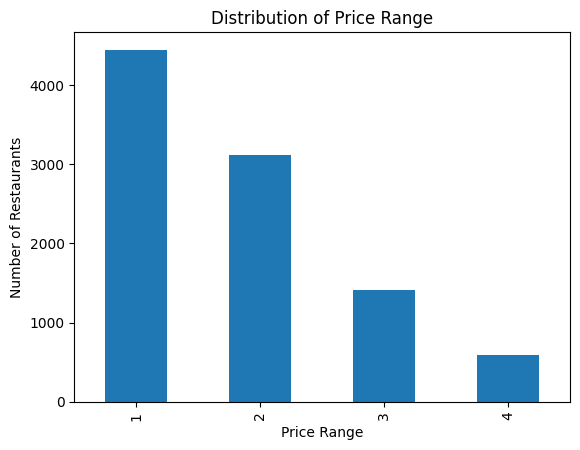

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
price_counts = df['Price range'].value_counts().sort_index()
price_counts.plot(kind='bar')
plt.title("Distribution of Price Range")
plt.xlabel("Price Range")
plt.ylabel("Number of Restaurants")
plt.show()

In [19]:

total = len(df)
percentage = ((price_counts / total) * 100).round(2)
print("Percentage of Restaurants in Each Price Range:")
print(percentage)

Percentage of Restaurants in Each Price Range:
Price range
1    46.53
2    32.59
3    14.74
4     6.14
Name: count, dtype: float64


## Task 3 – Price Range Distribution

Observation:
The distribution of price ranges shows the affordability level of most restaurants in the dataset.

A higher frequency of lower price ranges suggests that the majority of restaurants target budget or mid-range customers.

In [20]:

delivery_counts = df['Has Online delivery'].value_counts()
total = len(df)
percentage_delivery = ((delivery_counts / total) * 100).round(2)
print("Percentage of Restaurants Offering Online Delivery:")
print(percentage_delivery)

Percentage of Restaurants Offering Online Delivery:
Has Online delivery
No     74.34
Yes    25.66
Name: count, dtype: float64


In [21]:

avg_rating_delivery = df.groupby('Has Online delivery')['Aggregate rating'].mean()

print("\nAverage Ratings Comparison:")
print(avg_rating_delivery)


Average Ratings Comparison:
Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64


## Task 4 – Online Delivery Analysis

Observation:
This analysis examines how many restaurants provide online delivery services.

Comparing the ratings between restaurants with and without delivery helps determine whether offering online delivery influences customer satisfaction.

## Final Insights

• Certain cuisines dominate the restaurant market in the dataset.

• Some cities have significantly more restaurants than others, indicating stronger food industries.

• Most restaurants fall within mid-range price categories.

• Online delivery services are widely used and may influence customer engagement.


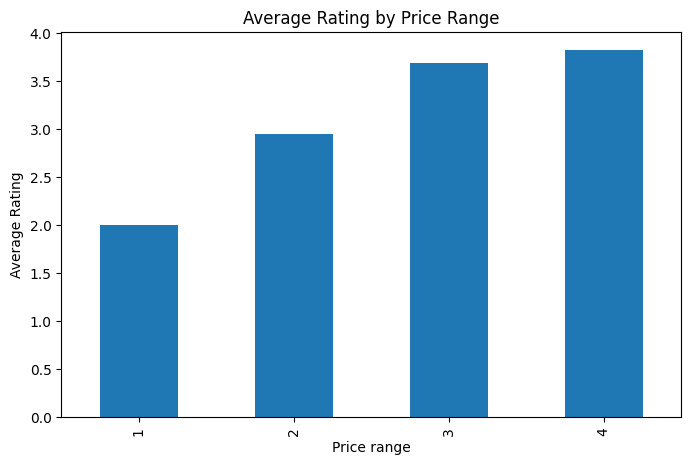

In [25]:
plt.figure(figsize=(8,5))
df.groupby('Price range')['Aggregate rating'].mean().plot(kind='bar')
plt.title("Average Rating by Price Range")
plt.ylabel("Average Rating")
plt.show()


Observation:
Restaurants in higher price ranges tend to receive slightly higher ratings,
suggesting that premium restaurants may provide better dining experiences.